# Nadaraya–Watson 核回归：用注意力做非参数预测

本节把上一节的注意力权重变成一个可以产生预测值的回归器。给定一个查询 $x$，模型会比较它与训练输入（keys）的距离，再把训练输出（values）按相似度加权平均。

核心公式是：

$$\hat y(x)=\sum_{i=1}^{n}\alpha(x,x_i)y_i,\qquad \alpha(x,x_i)\ge 0,\quad \sum_i\alpha(x,x_i)=1.$$

这里的权重由高斯核产生：距离越近，权重越大。你将依次看到：常数预测基线、固定核宽度的注意力回归，以及学习核宽度的 Nadaraya–Watson 网络。

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

## 1. 构造带噪声的回归数据

`f(x)` 是我们希望模型恢复的真实函数。训练集只有 50 个随机采样点，并加入标准差为 0.5 的高斯噪声；测试集则在 `[0, 5)` 上以 0.1 为间隔排列，用于画出连续预测曲线。

`torch.sort` 只对训练输入排序，不改变样本配对关系：排序后的 `x_train[i]` 仍对应 `y_train[i]`。这一步主要是为了让散点和后面的热图沿横轴呈现清晰的空间顺序。`y_truth` 不含噪声，是评估预测曲线时的参照。

In [2]:
n_train = 50  # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5)   # 排序后的训练样本

def f(x):
    return 2 * torch.sin(x) + x**0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))  # 训练样本的输出
x_test = torch.arange(0, 5, 0.1)  # 测试样本
y_truth = f(x_test)  # 测试样本的真实输出
n_test = len(x_test)  # 测试样本数
n_test

50

## 2. 先建立一个基线：所有位置都预测均值

`y_train.mean()` 是训练标签的整体均值。`torch.repeat_interleave` 把这个标量复制成 `n_test` 个预测，因此无论测试输入在哪里，预测曲线都是水平线。

这个基线很简单，却很有用：后续模型至少应该利用输入位置和邻近样本，明显优于这条水平线。如果复杂模型只学到均值，通常意味着权重没有正确归一化、输入形状错位，或训练没有真正更新参数。

In [3]:
def plot_kernel_reg(y_hat):
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'],
             xlim=[0, 5], ylim=[-1, 5])
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5);

## 3. 固定高斯核：注意力权重就是相似度

`X_repeat` 的形状是 `(n_test, n_train)`：第 `i` 行把同一个测试查询 `x_test[i]` 复制给所有训练样本。与 `x_train` 相减后，每个元素都是一个 query 与一个 key 的距离。

```python
attention_weights = softmax(-(query - key) ** 2 / 2, dim=1)
```

平方距离经过负号后送入 `softmax`：近邻得到较大的权重，远邻得到较小的权重；`dim=1` 保证每个 query 对所有训练 keys 的权重和为 1。矩阵乘法 `attention_weights @ y_train` 就是逐行加权平均。

这正是注意力的计算骨架：query 与 key 计算分数，softmax 得到权重，再汇聚 values。此处的 value 就是标量 `y_train`。

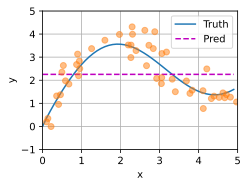

In [4]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

## 4. 用热图检查局部性

`attention_weights` 原本是二维的 `(n_test, n_train)`，为了复用上一节的 `show_heatmaps`，用两次 `unsqueeze` 变成 `(1, 1, n_test, n_train)`。纵轴是测试 queries，横轴是排序后的训练 keys。

如果模型确实在做局部平滑，较深的区域应当大致沿从左上到右下的方向移动：测试输入变大时，最高权重会从较小的训练输入转向较大的训练输入。热图还能帮助发现广播或 reshape 错误，因为错误的轴通常会产生不符合距离直觉的条纹。

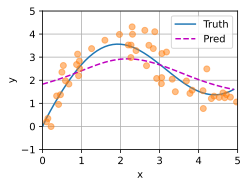

In [6]:
# X_repeat的形状:(n_test,n_train),
# 每一行都包含着相同的测试输入（例如：同样的查询）
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# x_train包含着键。attention_weights的形状：(n_test,n_train),
# 每一行都包含着要在给定的每个查询的值（y_train）之间分配的注意力权重
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)
# y_hat的每个元素都是值的加权平均值，其中的权重是注意力权重
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)

## 5. 为什么这里使用 `torch.bmm`

`torch.bmm` 是批量矩阵乘法，要求两个输入都是三维张量 `(batch, rows, cols)`。例如 `(2, 1, 4) @ (2, 4, 6)` 的结果形状是 `(2, 1, 6)`。

在回归器中，权重 `(batch, n_keys)` 通过 `unsqueeze(1)` 变成 `(batch, 1, n_keys)`，values `(batch, n_keys)` 通过 `unsqueeze(-1)` 变成 `(batch, n_keys, 1)`。批量乘法后得到 `(batch, 1, 1)`，再 `reshape(-1)` 还原为每个 query 一个标量预测。

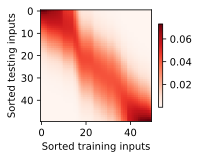

In [7]:
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')

## 6. 留一法训练可学习的核宽度

`NWKernelRegression` 把固定公式中的核宽度改成参数 `self.w`。注意力分数变为 `-((query - key) * w) ** 2 / 2`：`w` 越大，权重越集中在最近邻；`w` 越小，权重越平滑、覆盖更多 keys。

训练时不能让样本直接把自己的 `y_train` 作为 key-value 取回，否则模型可以通过把自身权重设为 1 获得虚假的低误差。因此 `keys` 和 `values` 使用单位矩阵布尔索引删除对角线，采用留一法：第 $i$ 个训练 query 只能参考其他 $n-1$ 个样本。

`loss(..., reduction='none')` 保留每个样本的误差，随后 `l.sum().backward()` 对所有样本求和后反向传播；SGD 只更新一个标量参数 `w`。

In [8]:
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))
torch.bmm(X, Y).shape

torch.Size([2, 1, 6])

## 7. 推理阶段：所有测试查询共享训练键值

训练完成后，`keys` 和 `values` 改为把完整训练集复制到每个测试 query。此时不再删除对角线，因为测试点通常不是训练点；每个测试位置都可以参考全部训练样本。

最终预测曲线应比均值基线更贴近 `y_truth`，但仍会呈现核回归的平滑特征。最后一张热图展示的是已训练网络实际使用的权重，可以和固定核的热图比较：参数 `w` 改变了注意力分布的尖锐程度。

In [9]:
weights = torch.ones((2, 10)) * 0.1
values = torch.arange(20.0).reshape((2, 10))
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))

tensor([[[ 4.5000]],

        [[14.5000]]])

In [10]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        # queries和attention_weights的形状为(查询个数，“键－值”对个数)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = nn.functional.softmax(
            -((queries - keys) * self.w)**2 / 2, dim=1)
        # values的形状为(查询个数，“键－值”对个数)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)

In [11]:
# X_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输入
X_tile = x_train.repeat((n_train, 1))
# Y_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输出
Y_tile = y_train.repeat((n_train, 1))
# keys的形状:('n_train'，'n_train'-1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# values的形状:('n_train'，'n_train'-1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

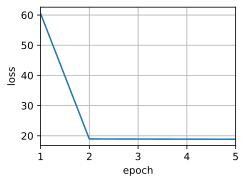

In [12]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    trainer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    animator.add(epoch + 1, float(l.sum()))

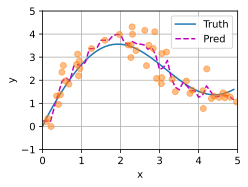

In [13]:
# keys的形状:(n_test，n_train)，每一行包含着相同的训练输入（例如，相同的键）
keys = x_train.repeat((n_test, 1))
# value的形状:(n_test，n_train)
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)

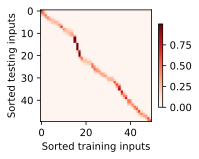

In [14]:
d2l.show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')

## 总结与练习

Nadaraya–Watson 回归把预测写成注意力汇聚：距离产生分数，softmax 产生归一化权重，权重再对 values 做加权平均。固定核版本说明机制；可学习版本通过参数 `w` 调整局部性，并用留一法避免训练样本直接看到自己的标签。

建议继续尝试：

1. 改变噪声标准差，观察均值基线和核回归曲线的变化。
2. 分别把初始 `w` 设为很大和很小，比较训练后的热图。
3. 将 `dim=1` 改成其他维度，预测会出现什么问题？用 `attention_weights.sum(dim=1)` 验证哪一维才是每个 query 的权重归一化维度。

读懂这套 query-key-value 数据流后，自注意力和多头注意力只是把标量输入、固定相似度函数扩展成向量表示和可学习的相似度函数。